In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [2]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [3]:
# Define steps
def step_1(state: CrashState) -> CrashState:
    print("Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30) # Simulate long-running hang
    return{"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("Step 3 executed")
    return {"step3": "done"}

In [4]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

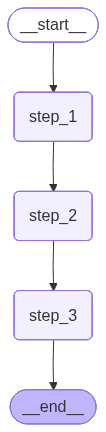

In [5]:
graph

In [6]:
try:
    print("Running graph: Please interrupt during step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": "thread-1"}})
except KeyboardInterrupt:
    print("Kernel mannually interrupted (crash simulated).")

Running graph: Please interrupt during step 2...
Step 1 executed
Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
Kernel mannually interrupted (crash simulated).


In [7]:
graph.get_state({"configurable": {"thread_id": "thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e0-d112-6c16-8001-aba39d24b961'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-05T16:24:52.511416+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e0-d109-68c2-8000-f907c16d29f4'}}, tasks=(PregelTask(id='5e849541-2d7d-ec7c-a6b4-84da5f953ddb', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [9]:
list(graph.get_state_history({"configurable": {"thread_id": "thread-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e0-d112-6c16-8001-aba39d24b961'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-05T16:24:52.511416+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e0-d109-68c2-8000-f907c16d29f4'}}, tasks=(PregelTask(id='5e849541-2d7d-ec7c-a6b4-84da5f953ddb', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e0-d109-68c2-8000-f907c16d29f4'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-05T16:24:52.507648+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch

In [10]:
# 6. Rerun to show fault-tolerant resume
final_state = graph.invoke(None, config = {"configurable": {"thread_id": "thread-1"}})
print("\n Final State:", final_state)

Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
Step 3 executed

 Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [11]:
graph.get_state({"configurable": {"thread_id": "thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e7-eb9f-6d46-8003-559b254efce8'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-05T16:28:03.200322+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e7-eb9d-6492-8002-06c3a05bd693'}}, tasks=(), interrupts=())

In [12]:
list(graph.get_state_history({"configurable": {"thread_id": "thread-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e7-eb9f-6d46-8003-559b254efce8'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-05T16:28:03.200322+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e7-eb9d-6492-8002-06c3a05bd693'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e7-eb9d-6492-8002-06c3a05bd693'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-05T16:28:03.199267+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1788e0-d112-6c16-8001-aba39d24b961'}}, tasks=(PregelTask(id='06742dfb-0602-348f